In [4]:
import pandas as pd
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
import numpy as np
import pandas as pd


ModuleNotFoundError: No module named 'seaborn'

In [12]:
!pip install seaborn 

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


You should consider upgrading via the 'C:\Users\knrre\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [13]:
import seaborn as sns

In [73]:
data=sns.load_dataset('titanic')
data.head(2)
data.info

<bound method DataFrame.info of      survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_m

In [61]:
df=data[['survived','pclass','sex','age','fare']]
df

,survived,pclass,sex,age,fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500
...,...,...,...,...,...
886,0,2,male,27.0,13.0000
887,1,1,female,19.0,30.0000
888,0,3,female,NaN,23.4500
889,1,1,male,26.0,30.0000


#before performing the transoformation make sure it doenst have negative(for log transform ) and null values

In [62]:
df.isnull().sum()
df['age'].fillna(df['age'].mean(),inplace=True)

C:\Users\knrre\AppData\Local\Temp\ipykernel_27768\4219545421.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(),inplace=True)
C:\Users\knrre\AppData\Local\Temp\ipykernel_27768\4219545421.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age'].fillna(df['age'].mean(),inplace=True)


In [64]:
df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
fare        0
dtype: int64

In [88]:

df.info



df.describe

df['fare']=df['fare'].astype(int)
df.head()

C:\Users\knrre\AppData\Local\Temp\ipykernel_27768\2324278390.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['fare']=df['fare'].astype(int)


,survived,pclass,sex,age,fare
0,0,3,male,22.0,7
1,1,1,female,38.0,71
2,1,3,female,26.0,7
3,1,1,female,35.0,53
4,0,3,male,35.0,8


In [89]:
df.head()

,survived,pclass,sex,age,fare
0,0,3,male,22.0,7
1,1,1,female,38.0,71
2,1,3,female,26.0,7
3,1,1,female,35.0,53
4,0,3,male,35.0,8


In [90]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt 


In [91]:
#we shall split the data into train and test 1st

X_train,X_test,y_train,y_test=train_test_split(df.drop('survived',axis=1),df['survived'],test_size=0.2,random_state=42)

In [92]:
X_train.shape,X_test.shape,y_test.shape,y_train.shape

((712, 4), (179, 4), (179,), (712,))

In [94]:
import scipy.stats  as stats

TypeError: subplot() takes 1 or 3 positional arguments but 0 were given

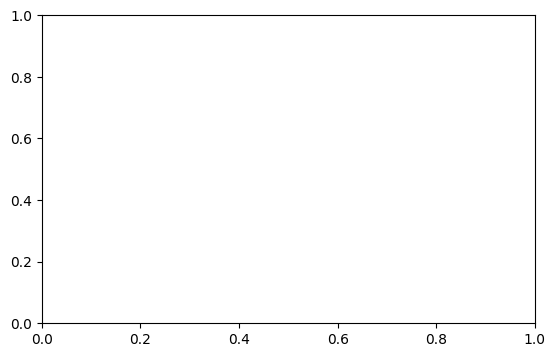

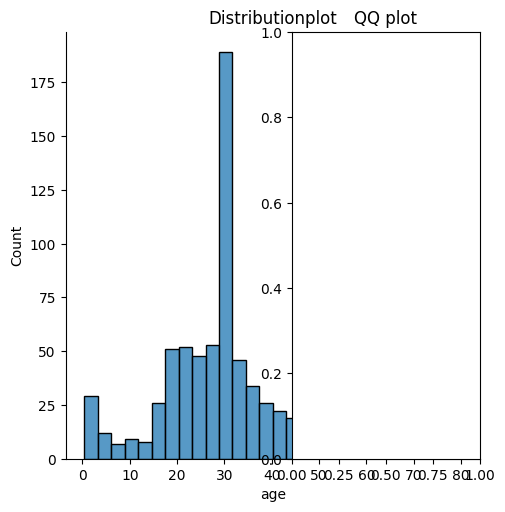

In [104]:
#we shall see how the data is distributed using the ProbabiltyDisrtibution and QQ graph

plt.figure(figsize=(14,4))
plt.subplot(121)
sns.displot(X_train['age'])
plt.title("Distributionplot")

plt.subplot(122)
stats.probplot(X_train['age'],dist='norm')
plt.title("QQ plot")
plt.show()


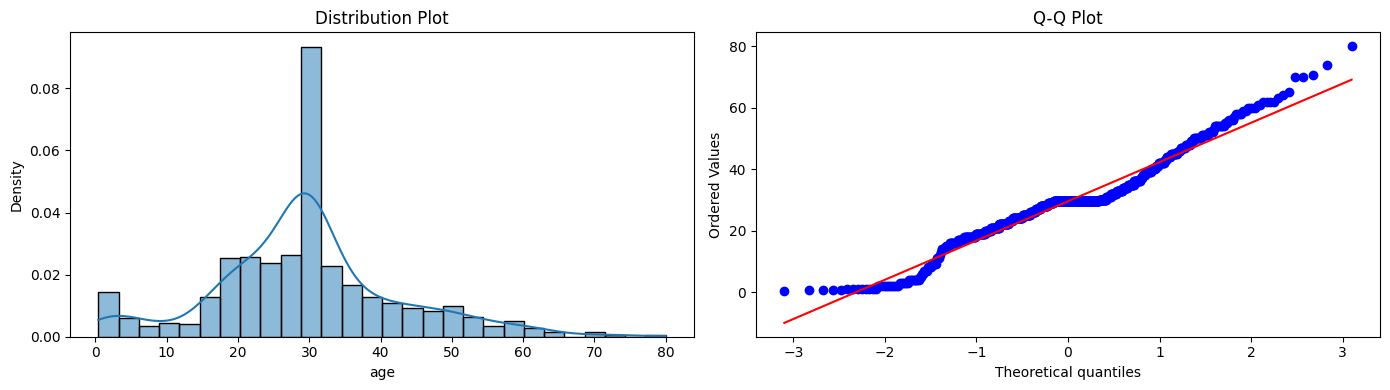

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. Initialize the figure canvas (lowercase 'f')
plt.figure(figsize=(14, 4))

# 2. Left side: Probability Distribution Curve
plt.subplot(121)  
sns.histplot(X_train['age'], kde=True, stat="density")  # histplot fits perfectly inside subplots
plt.title("Distribution Plot")

# 3. Right side: Q-Q Plot
plt.subplot(122)
stats.probplot(X_train['age'], dist="norm", plot=plt)  # added plot=plt to render it here
plt.title("Q-Q Plot")

# 4. Show the clean layout
plt.tight_layout() 




plt.show()


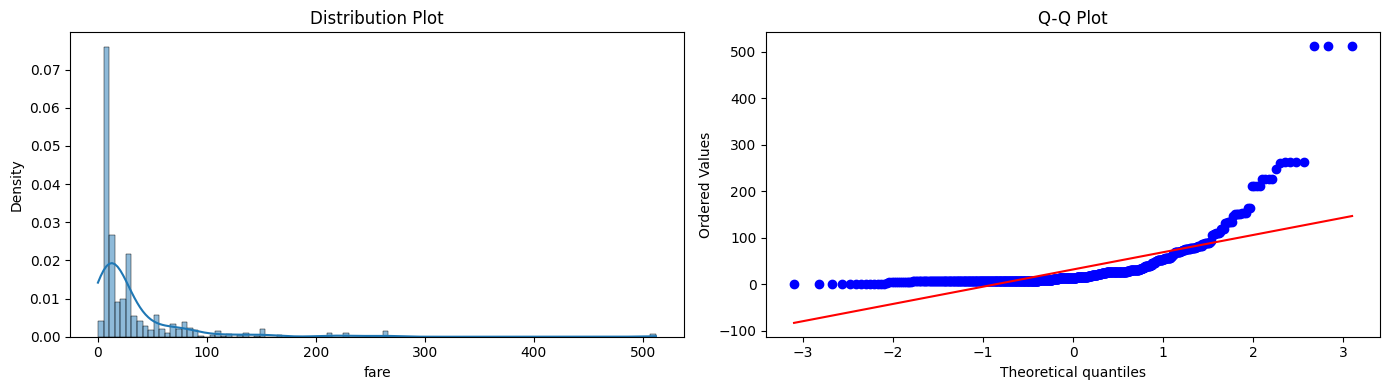

In [108]:
# 1. Initialize the figure canvas (lowercase 'f')
plt.figure(figsize=(14, 4))

# 2. Left side: Probability Distribution Curve
plt.subplot(121)  
sns.histplot(X_train['fare'], kde=True, stat="density")  # histplot fits perfectly inside subplots
plt.title("Distribution Plot")

# 3. Right side: Q-Q Plot
plt.subplot(122)
stats.probplot(X_train['fare'], dist="norm", plot=plt)  # added plot=plt to render it here
plt.title("Q-Q Plot")

# 4. Show the clean layout
plt.tight_layout() 




plt.show()

#here we can see that the fare is right skewed


In [ ]:
X_train